In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set(style='whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df = pd.read_csv("demand_forecasting.csv")
print(df.head(10))
# Convert Date from obj -> datetime
print(df.dtypes)
df['Date'] = pd.to_datetime(df['Date'])
print(df.info())

# DATA CLEANING

# Null/missing values, Duplicates, etc
print(df.isna().sum().sum())
print(df.duplicated().sum())

# Statistical Measures of dataset - Count, Min, Max, Mean, 255 Quartile, 505 Quartile, 75% Quartile, S.D
print(df.describe().T)
print(df.describe(include='object').T)

# Add Year, Month, Day, Weekday columns using Date column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001  Electronics  North              195   
1  2022-01-01     S001      P0002     Clothing  North              117   
2  2022-01-01     S001      P0003     Clothing  North              247   
3  2022-01-01     S001      P0004  Electronics  North              139   
4  2022-01-01     S001      P0005    Groceries  North              152   
5  2022-01-01     S001      P0006         Toys  North              209   
6  2022-01-01     S001      P0007    Groceries  North              118   
7  2022-01-01     S001      P0008  Electronics  North              244   
8  2022-01-01     S001      P0009     Clothing  North              115   
9  2022-01-01     S001      P0010    Furniture  North              192   

   Units Sold  Units Ordered   Price  Discount Weather Condition  Promotion  \
0         102            252   72.72         5             Snowy          0   
1         117            24

<Figure size 1000x600 with 0 Axes>

In [4]:
# KPIs - Discounted Price, Sell Through Rate
df['Discounted Price'] = df['Price'] * (1 - df['Price'] / 100)
df['Sell Through Rate'] = df['Units Sold'] / df['Inventory Level']
print(df.head(1))
print(df['Sell Through Rate'].describe())

# Aggregate Demand by Category
print(df.groupby('Category')['Demand'].agg(['mean', 'sum', 'std']).sort_values(by = 'sum', ascending=False))

# Aggregate Demand by Region, Seasonality
print(df.groupby(['Region', 'Seasonality'])['Demand'].mean())
# Aggregate Demand by Promotion - Does running a promotion actually increase average demand?
print(df.groupby('Promotion')['Demand'].mean())

        Date Store ID Product ID     Category Region  Inventory Level  \
0 2022-01-01     S001      P0001  Electronics  North              195   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  Year  Month  Day  \
0               85.73      Winter         0     115  2022      1    1   

    Weekday  Discounted Price  Sell Through Rate  
0  Saturday         19.838016           0.523077  
count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64
                   mean      sum        std
Category                                   
Groceries    120.976447  3677684  48.362730
Clothing     112.619737  1369456  41.022968
Furniture     73.581140  1006590  32.336141
Toys       

Category    Clothing  Electronics  Furniture   Groceries        Toys
Month                                                               
1         126.997962    99.519022  75.690821  117.399457   94.242236
2         128.966518    84.184524  61.625992  103.522768   68.885204
3         105.835685   108.120968  84.015233  126.561694  128.273041
4         106.972917    85.916667  63.005556  105.111250   85.753571
5         108.650202    79.577957  56.036738   98.637903   71.756912
6         105.670833   106.922222  79.908333  147.772500  100.825000
7         107.838710    87.418011  66.156810  128.744355   74.366359
8         107.871976   109.733871  83.524194  149.875403  102.794931
9         105.118750   105.015278  81.854630  122.239167  102.722619
10        107.113911    89.354839  69.279570  109.765323   80.857143
11        106.306250   107.495833  82.033333  122.121250  100.138095
12        127.865927   104.750000  78.067204  120.438306   98.194700


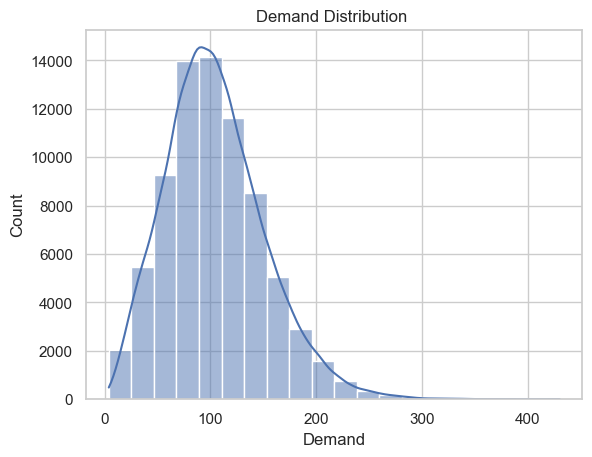

In [5]:
# EXPORATORY DATA ANALYSIS (EDA) — understanding your data's shape, distributions, and group differences before building any forecasting model

# Pivot Table using Pandas. Mean Monthly Demand by Category.
print(pd.pivot_table(df, values='Demand', index='Month', columns='Category', aggfunc='mean'))

# Seaborn's Histogram plot - Counts how many rows fall into each demand range (bucket/bin)
# Draw a smooth curve (Kernel Density Estimate) over the bars
# The distribution is RIGHT-SKEWED — a long tail toward 400, meaning high-demand events are rare but do happen
# Count - the number of rows (transactions/records) in your dataset that fall within each demand range
# The right skew (long tail) tells you extreme demand spikes exist but are rare — likely driven by promotions, seasons, or epidemics (columns you already have!)
# A skewed distribution like this often needs log transformation before feeding into ML models to perform well
sns.histplot(df['Demand'], bins=20, kde=True)
plt.title("Demand Distribution ")
plt.show()

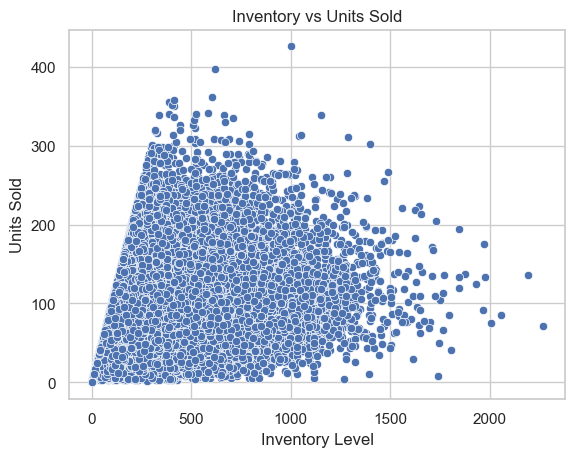

In [6]:
# Scatter Plot - Units Sold vs Inventory
sns.scatterplot(data=df, x='Inventory Level', y='Units Sold')
plt.title('Inventory vs Units Sold')
plt.show()

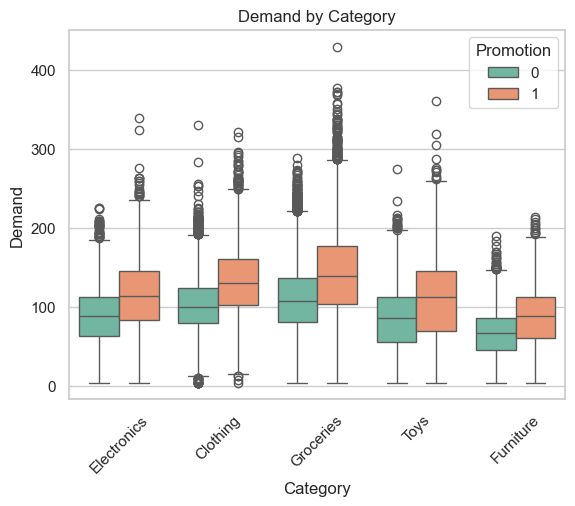

In [7]:
# Box Plot -
sns.boxplot(data=df, x='Category', y='Demand', hue='Promotion', palette='Set2')
plt.xticks(rotation=45)
plt.title('Demand by Category')
plt.show()

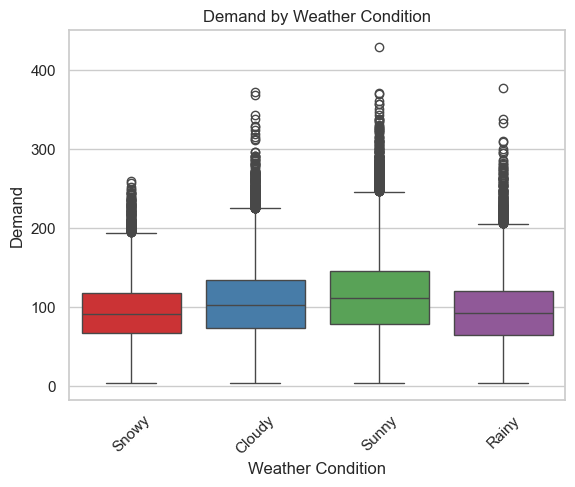

In [8]:
# Box Plot -
sns.boxplot(data=df, x='Weather Condition', y='Demand', palette='Set1', hue='Weather Condition')
plt.xticks(rotation=45)
plt.title('Demand by Weather Condition')
plt.show()

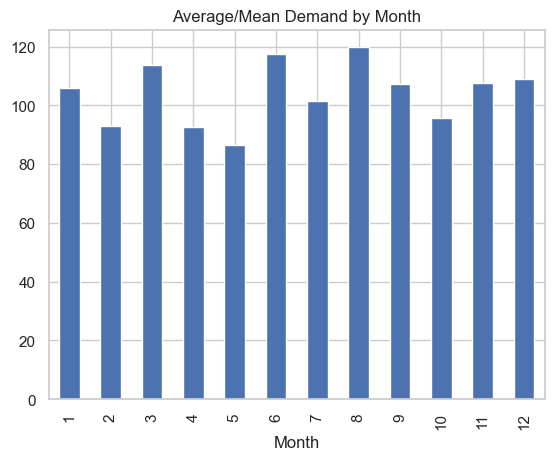

In [9]:
# TIME SERIES ANALYSIS
monthly_demand = df.groupby('Month')['Demand'].mean()
monthly_demand.plot(kind='bar')
plt.title('Average/Mean Demand by Month')
plt.show()

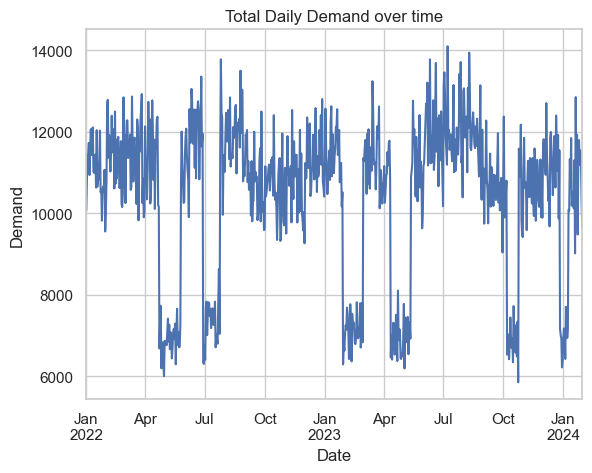

In [10]:
daily_demand = df.groupby('Date')['Demand'].sum()
daily_demand.plot()
plt.title('Total Daily Demand over time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

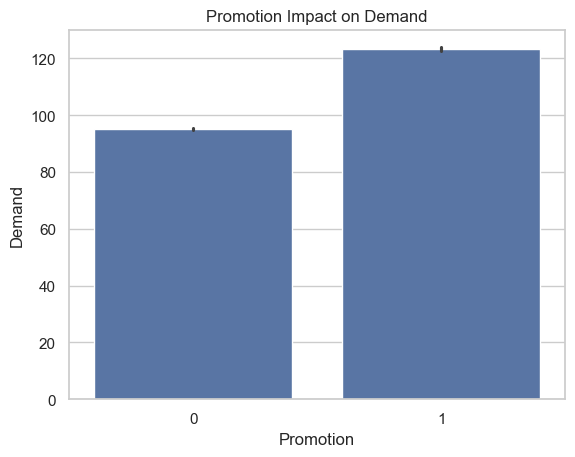

In [11]:
# With Promotion, Demand increases
sns.barplot(data=df, x='Promotion', y='Demand')
plt.title('Promotion Impact on Demand')
plt.show()

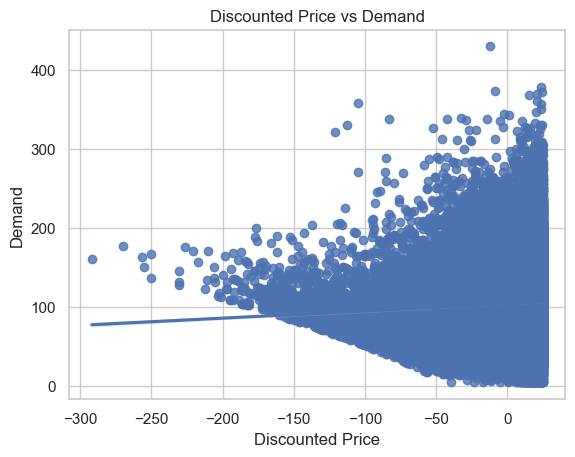

In [12]:
# Price - Demand relationship. 
sns.regplot(data = df, x = 'Discounted Price', y = 'Demand')
plt.title('Discounted Price vs Demand')
plt.show()

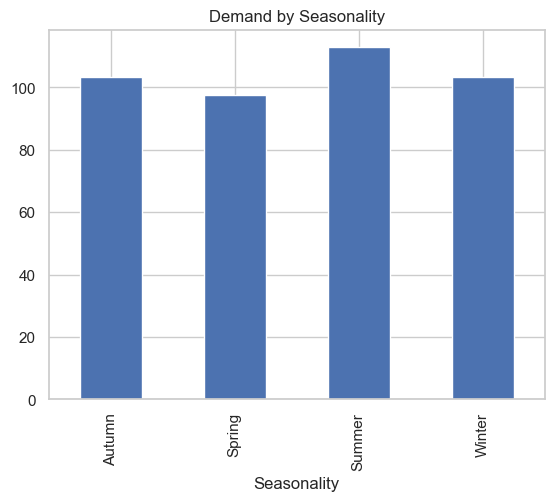

In [15]:
# Check Seasonality, Epidemic effects on Demand
df.groupby('Seasonality')['Demand'].mean().plot(kind='bar')
plt.title('Demand by Seasonality')
plt.show()

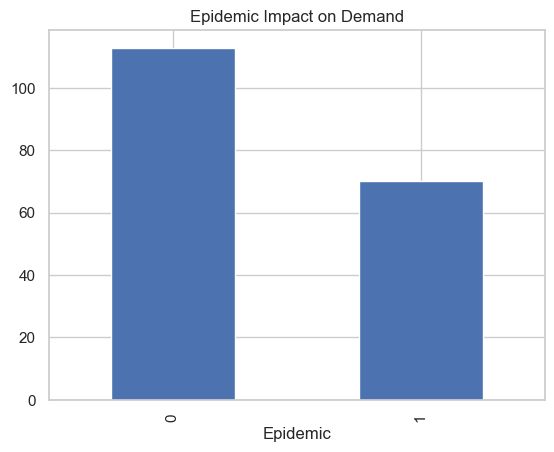

In [17]:
# Check Seasonality, Epidemic effects on Demand. Whe epidemic happens, lower demand, & vice versa
df.groupby('Epidemic')['Demand'].mean().plot(kind='bar', title='Epidemic Impact on Demand')
plt.show()

In [18]:
df.to_csv('preprocessed_demand_forecasting_data.csv')